Workflow:
1. Load & inspect the data
2. Clean & preprocess (handle missing values, encode categorical features, scale numeric features)
3. Exploratory Data Analysis (EDA)
4. Determine optimal number of clusters (Elbow Method + Silhouette Score)
5. Train the K-Means model
6. Visualize & interpret the clusters
7. Profile each segment and export results


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
%matplotlib inline

RANDOM_STATE = 42


In [23]:
df = pd.read_csv(r"C:\Users\User\Recess Term\Gihozo_Patrick\Machine learning\Unsupervised\Data\Mall_Customers.csv")
print("Shape:", df.shape)
df.head()


Shape: (1000, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [24]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 39.2 KB


In [25]:
df.describe(include='all')


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,997,994.000000,996.000000,994.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,F,NaN,NaN,NaN
freq,NaN,522,NaN,NaN,NaN
mean,1499.500000,NaN,38.935614,57.149096,42.645875
std,288.819436,NaN,13.399880,28.628506,20.101589
min,1000.000000,NaN,18.000000,15.000000,1.000000
25%,1249.750000,NaN,30.000000,34.975000,31.000000
50%,1499.500000,NaN,36.000000,49.000000,47.000000
75%,1749.250000,NaN,44.000000,79.400000,57.000000


In [26]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique Gender values:", df['Gender'].unique())


Missing values per column:
CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

Duplicate rows: 0

Unique Gender values: <StringArray>
['M', 'F', nan]
Length: 3, dtype: str


In [27]:
# Drop rows where Gender is missing (very few), impute numeric missing values with the median
df_clean = df.copy()

# Numeric columns to impute
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Filled {col} missing values with median = {median_val}")

# Drop rows with missing Gender (small number, not worth imputing categorical guesswork)
before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=['Gender']).reset_index(drop=True)
print(f"\nDropped {before - df_clean.shape[0]} rows with missing Gender")

print("\nRemaining missing values:\n", df_clean.isnull().sum())
print("\nFinal shape:", df_clean.shape)


Filled Age missing values with median = 36.0
Filled Annual Income (k$) missing values with median = 49.0
Filled Spending Score (1-100) missing values with median = 47.0

Dropped 3 rows with missing Gender

Remaining missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Final shape: (997, 5)


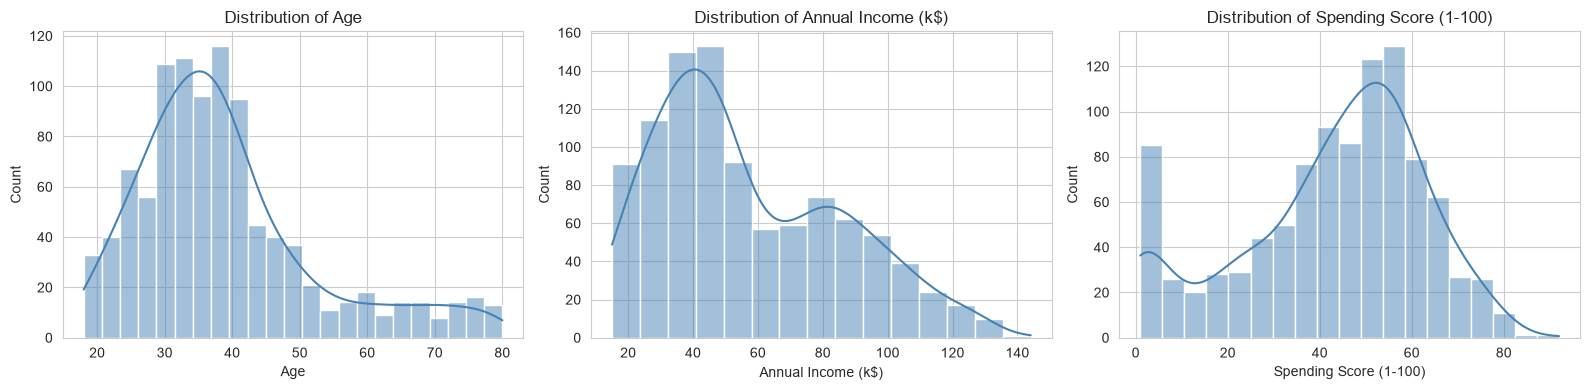

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


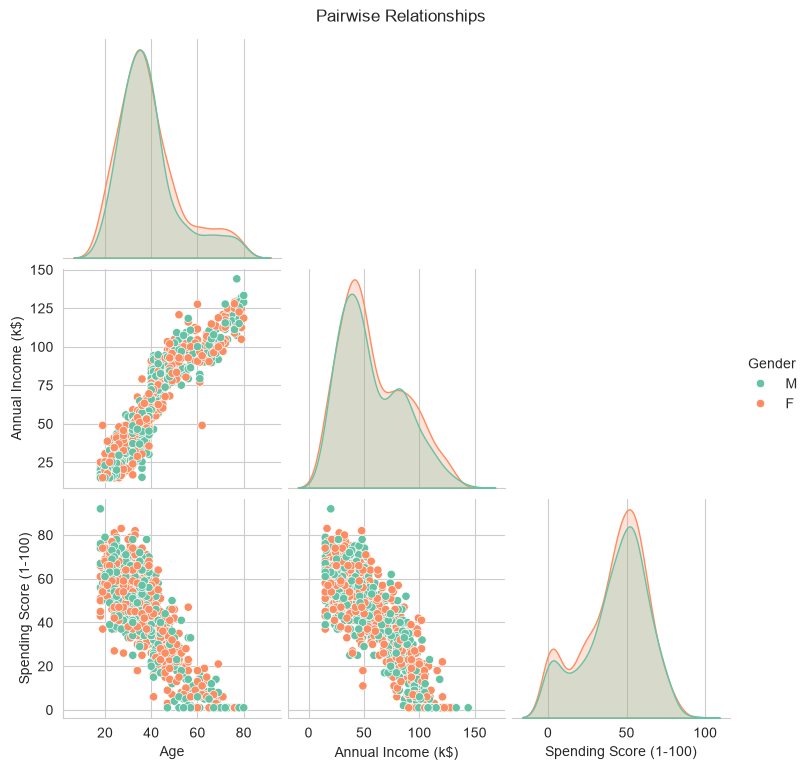

In [29]:
sns.pairplot(df_clean[numeric_cols + ['Gender']], hue='Gender', palette='Set2', corner=True)
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()


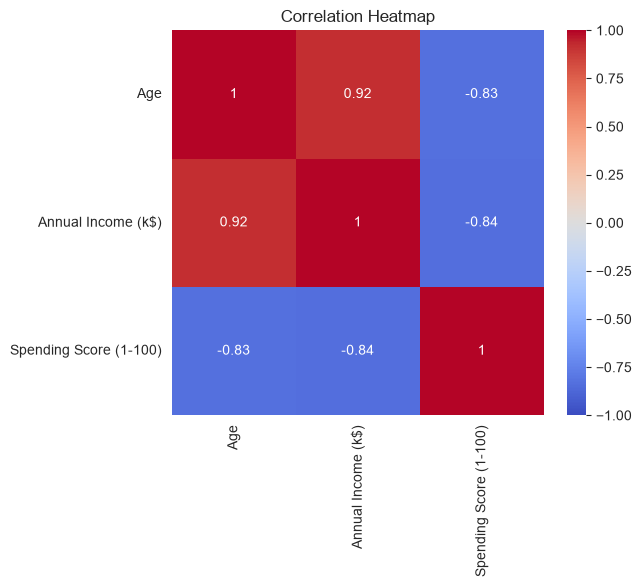

In [30]:
plt.figure(figsize=(6, 5))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()


In [31]:
le = LabelEncoder()
df_clean['Gender_encoded'] = le.fit_transform(df_clean['Gender']) 

# Feature set A: classic 2-feature segmentation
features_2d = ['Annual Income (k$)', 'Spending Score (1-100)']
X_2d = df_clean[features_2d].values

# Feature set B: richer segmentation
features_full = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_full = df_clean[features_full].values

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

print("2D feature matrix shape:", X_2d_scaled.shape)
print("Full feature matrix shape:", X_full_scaled.shape)


2D feature matrix shape: (997, 2)
Full feature matrix shape: (997, 3)


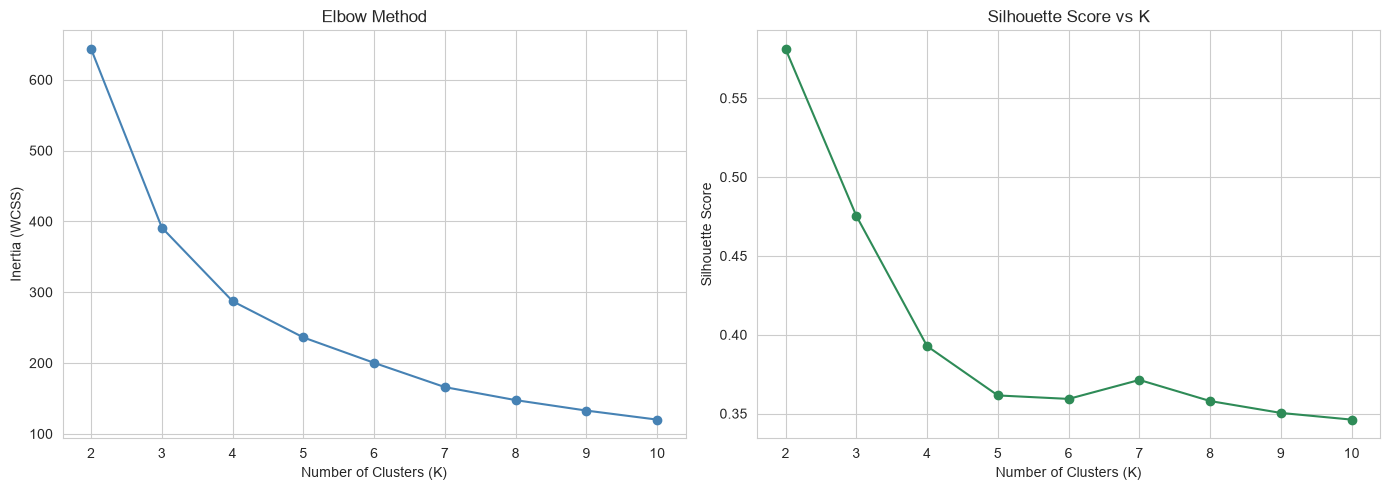

Best K by silhouette score: 2


In [32]:
def evaluate_k_range(X, k_range=range(2, 11)):
    inertias = []
    sil_scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels))
    return list(k_range), inertias, sil_scores

k_range = range(2, 11)
ks, inertias, sil_scores = evaluate_k_range(X_2d_scaled, k_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ks, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')

axes[1].plot(ks, sil_scores, marker='o', color='seagreen')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
plt.tight_layout()
plt.show()

best_k = ks[int(np.argmax(sil_scores))]
print(f"Best K by silhouette score: {best_k}")


In [33]:
K_OPTIMAL = best_k  

print(f"Using K = {K_OPTIMAL}")


Using K = 2


In [34]:
kmeans_2d = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=10, random_state=RANDOM_STATE)
df_clean['Cluster'] = kmeans_2d.fit_predict(X_2d_scaled)

print("Cluster sizes:")
print(df_clean['Cluster'].value_counts().sort_index())


Cluster sizes:
Cluster
0    331
1    666
Name: count, dtype: int64


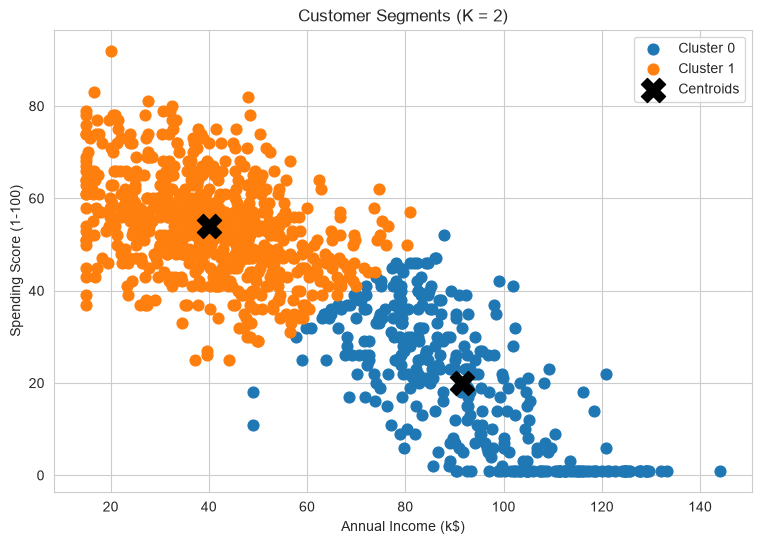

In [35]:
plt.figure(figsize=(9, 6))
palette = sns.color_palette('tab10', n_colors=K_OPTIMAL)

for cluster_id in sorted(df_clean['Cluster'].unique()):
    subset = df_clean[df_clean['Cluster'] == cluster_id]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                s=60, color=palette[cluster_id], label=f'Cluster {cluster_id}')

# Plot centroids (inverse-transform back to original scale)
centroids_original = scaler_2d.inverse_transform(kmeans_2d.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            s=300, color='black', marker='X', label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Customer Segments (K = {K_OPTIMAL})')
plt.legend()
plt.show()


In [36]:
cluster_profile = df_clean.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_profile['Count'] = df_clean['Cluster'].value_counts().sort_index()
cluster_profile


,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,53.4,91.6,20.1,331
1,31.7,40.0,53.9,666


In [37]:
gender_by_cluster = pd.crosstab(df_clean['Cluster'], df_clean['Gender'], normalize='index').round(2) * 100
gender_by_cluster.columns = [f'{c} %' for c in gender_by_cluster.columns]
gender_by_cluster


,F %,M %
Cluster,,
0,53.0,47.0
1,52.0,48.0


C:\Users\User\AppData\Local\Temp\ipykernel_18092\513577583.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Cluster', y=col, ax=ax, palette='tab10')
C:\Users\User\AppData\Local\Temp\ipykernel_18092\513577583.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Cluster', y=col, ax=ax, palette='tab10')
C:\Users\User\AppData\Local\Temp\ipykernel_18092\513577583.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Cluster', y=col, ax=ax, palette='tab10')


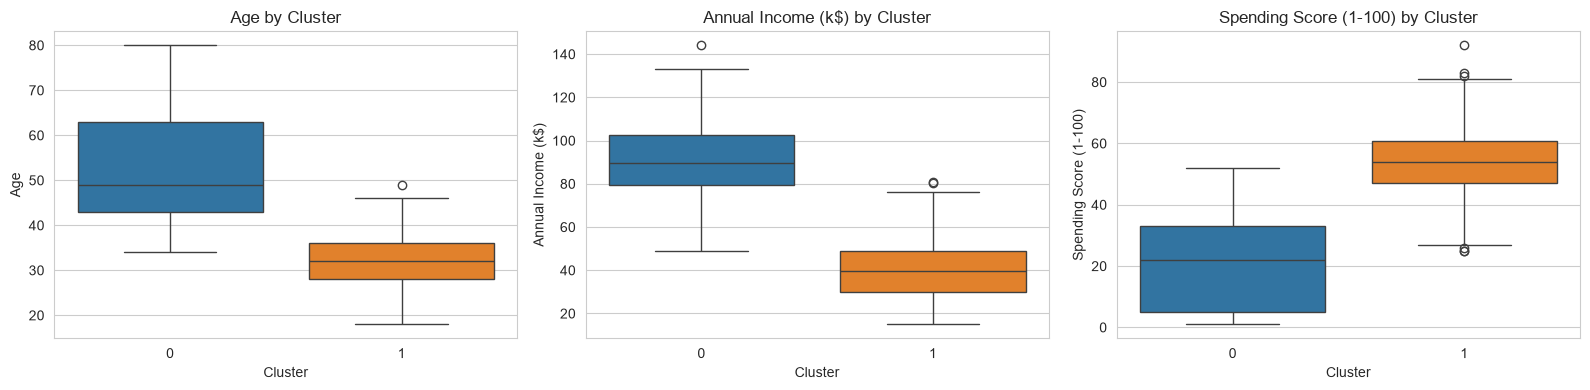

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.boxplot(data=df_clean, x='Cluster', y=col, ax=ax, palette='tab10')
    ax.set_title(f'{col} by Cluster')
plt.tight_layout()
plt.show()


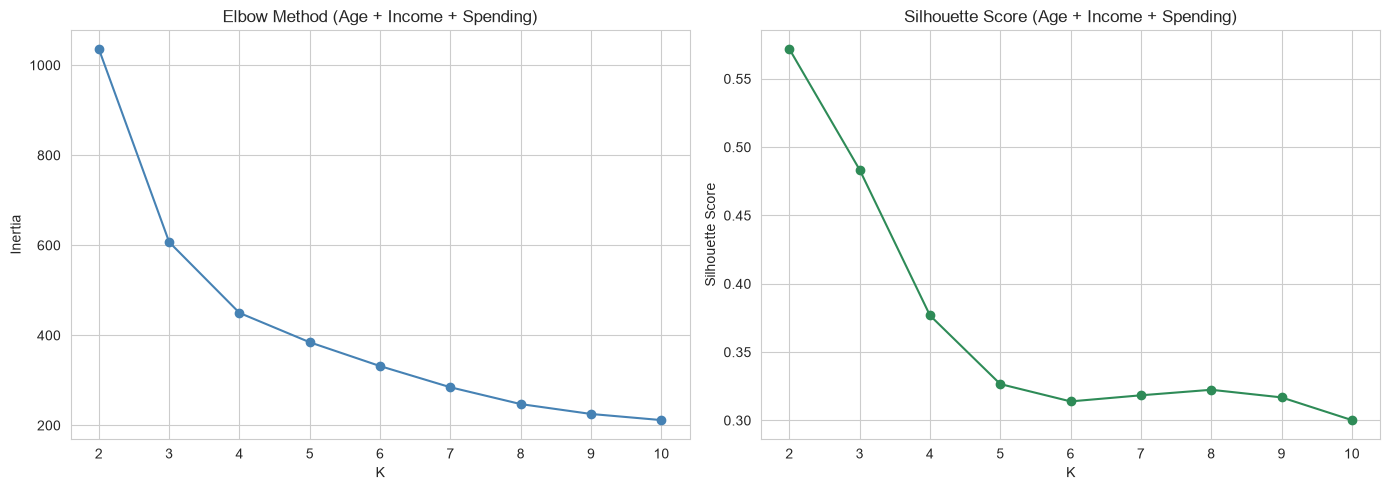

Best K for full feature set: 2


In [39]:
ks_full, inertias_full, sil_full = evaluate_k_range(X_full_scaled, range(2, 11))
best_k_full = list(range(2, 11))[int(np.argmax(sil_full))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2, 11), inertias_full, marker='o', color='steelblue')
axes[0].set_title('Elbow Method (Age + Income + Spending)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(range(2, 11), sil_full, marker='o', color='seagreen')
axes[1].set_title('Silhouette Score (Age + Income + Spending)')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

print(f"Best K for full feature set: {best_k_full}")


Explained variance by 2 PCA components: 97.33%


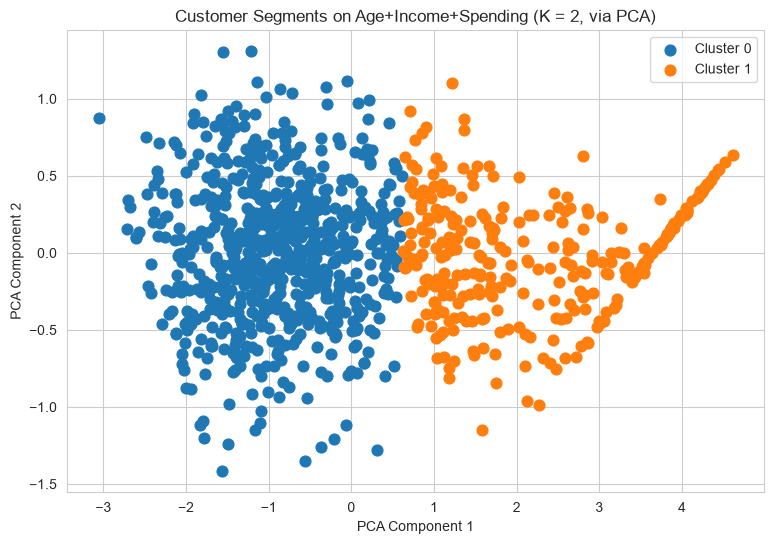

In [40]:
kmeans_full = KMeans(n_clusters=best_k_full, init='k-means++', n_init=10, random_state=RANDOM_STATE)
df_clean['Cluster_full'] = kmeans_full.fit_predict(X_full_scaled)

# Reduce to 2D with PCA purely for visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_full_scaled)
print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(9, 6))
palette_full = sns.color_palette('tab10', n_colors=best_k_full)
for cluster_id in sorted(df_clean['Cluster_full'].unique()):
    mask = df_clean['Cluster_full'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=60, color=palette_full[cluster_id],
                label=f'Cluster {cluster_id}')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'Customer Segments on Age+Income+Spending (K = {best_k_full}, via PCA)')
plt.legend()
plt.show()


In [41]:
cluster_profile_full = df_clean.groupby('Cluster_full')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_profile_full['Count'] = df_clean['Cluster_full'].value_counts().sort_index()
cluster_profile_full


,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster_full,,,,
0,32.1,41.4,53.1,700
1,55.0,94.1,18.1,297


In [42]:
output_path = 'mall_customers_clustered.csv'
df_clean.to_csv(output_path, index=False)
print(f"Saved clustered dataset to {output_path}")
df_clean.head()


Saved clustered dataset to mall_customers_clustered.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_encoded,Cluster,Cluster_full
0,1000,M,39.0,59.9,58.0,1,1,0
1,1001,M,34.0,48.4,37.0,1,1,0
2,1002,F,40.0,70.5,26.0,0,0,1
3,1003,F,47.0,81.1,30.0,0,0,1
4,1004,F,33.0,42.1,58.0,0,1,0
